In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from collections import defaultdict
from scipy.stats import norm
from matplotlib.colors import ListedColormap

In [2]:
# data_path = "data/finegrain/2025-11-10_NASA-FTJ-04_ID10-05_PWR.csv"
data_path = "data/8300_2025-11-13_NASA-FTJ-04_ID05-29_LTP-LTD.csv"
df = pd.read_csv(data_path, skiprows=21)

In [3]:
#Show name of the columns
print(df.columns)

Index(['cycle\tV_write\tR_neg_ohm\tR_pos_ohm\tI_neg_A\tI_pos_A\tJ_neg_A_per_m2\tJ_pos_A_per_m2\tVread_min_V\tVread_max_V'], dtype='object')


In [4]:
#Split the columns when \t is present
df = df['cycle\tV_write\tR_neg_ohm\tR_pos_ohm\tI_neg_A\tI_pos_A\tJ_neg_A_per_m2\tJ_pos_A_per_m2\tVread_min_V\tVread_max_V'].str.split('\t', expand=True)
#Save this dataframe as csv
df.to_csv('processed_data.csv', index=False)

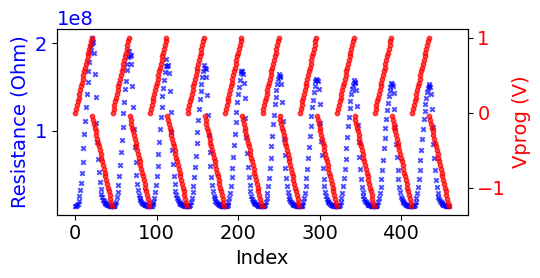

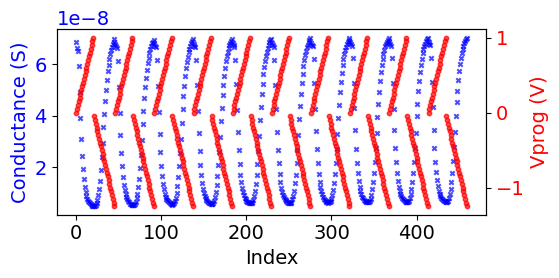

In [5]:
cycle = df[0]
V_write = df[1]
R = df[3]
G = 1 / R.astype(float)
R_array = np.array(R.astype(float))
V_write_array = np.array(V_write.astype(float))
G_array = np.array(G.astype(float))

indices = np.arange(len(R)) 
plt.figure(figsize=(6,3))
#Set font size to 14
plt.rcParams.update({'font.size': 14})

#Make another Y axis on the right side for V_write
ax = plt.gca()

# plot R on the left y-axis
ax.scatter(indices, R_array, c='blue', s=10, label='R (Ohm)', marker="x", alpha=0.7)
ax.set_ylabel('Resistance (Ohm)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# create a twin axis for V_write on the right y-axis
ax2 = ax.twinx()
ax2.scatter(indices, V_write_array, c='red', s=10, label='V_write (V)', marker='o', alpha=0.7)
ax2.set_ylabel('Vprog (V)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax.set_xlabel('Index')

#Save the figure as svg
plt.tight_layout()
plt.savefig('R_and_Vwrite_vs_Index.svg')

plt.figure(figsize=(6,3))
#Set font size to 14
plt.rcParams.update({'font.size': 14})

#Make another Y axis on the right side for V_write
ax = plt.gca()

# plot R on the left y-axis
ax.scatter(indices, G_array, c='blue', s=10, label='G (S)', marker="x", alpha=0.7)
ax.set_ylabel('Conductance (S)', color='blue')
ax.tick_params(axis='y', labelcolor='blue')

# create a twin axis for V_write on the right y-axis
ax2 = ax.twinx()
ax2.scatter(indices, V_write_array, c='red', s=10, label='V_write (V)', marker='o', alpha=0.7)
ax2.set_ylabel('Vprog (V)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

ax.set_xlabel('Index')

#Save the figure as svg
plt.tight_layout()
file_name = os.path.splitext(os.path.basename(data_path))[0]
plt.savefig(f'plots/G_and_Vwrite_vs_Index_{file_name}.svg')



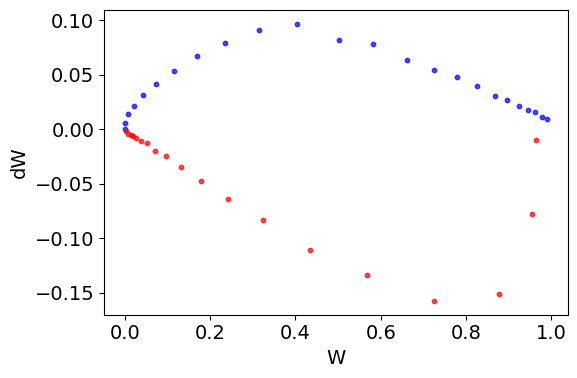

In [6]:
#After index 200, find the index where V_write changes from positive to negative and take one cycle of data from this index until index changes again from positive to negative
cycle_start_indices = []
for i in range(1, len(V_write_array)-1):
    if V_write_array[i-1] > 0 and V_write_array[i] < 0:
        cycle_start_indices.append(i)
#Take one cycle of data from cycle_start_indices[0] to cycle_start_indices[1]
start_index = cycle_start_indices[3]
end_index = cycle_start_indices[4]
cycle_V_write = V_write_array[start_index:end_index]
cycle_R = R_array[start_index:end_index]
cycle_G = G_array[start_index:end_index]
Gmin = np.min(cycle_G)
Gmax = np.max(cycle_G)
W = (cycle_G - Gmin) / (Gmax - Gmin)

W_LTP = W[cycle_V_write < 0]
W_LTD = W[cycle_V_write > 0]

# W_LTP: original weight list (N values)

Winit_LTP = W_LTP[:-1]         # all except last
Wfinal_LTP = W_LTP[1:]         # all except first
dW_LTP = Wfinal_LTP - Winit_LTP
W_LTP = Winit_LTP  # update W_LTP to match dW_LTP length

# W_LTD: original weight list (N values)
Winit_LTD = W_LTD[:-1]         # all except last
Wfinal_LTD = W_LTD[1:]         # all except first
dW_LTD = Wfinal_LTD - Winit_LTD
W_LTD = Winit_LTD  # update W_LTD to match dW_LTD length



#Plot dW against W for LTP and LTD
plt.figure(figsize=(6,4))
plt.scatter(W_LTP, dW_LTP, c='blue', s=10, label='LTP', alpha=0.7)
plt.scatter(W_LTD, dW_LTD, c='red', s=10, label='LTD', alpha=0.7)
plt.xlabel('W')
plt.ylabel('dW')

#Save the processed data as csv

plt.tight_layout()
plt.savefig(f'dW_vs_W_{file_name}.svg')





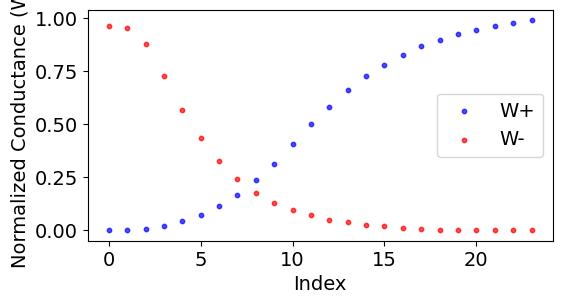

In [7]:
#Pad the last indexes of shorter array with last value
max_length = max(len(W_LTP), len(W_LTD))
W_LTP_padded = np.pad(W_LTP, (0, max_length - len(W_LTP)), 'edge')
W_LTD_padded = np.pad(W_LTD, (0, max_length - len(W_LTD)), 'edge')
#Plot W_LTP_padded and W_LTD_padded vs index
plt.figure(figsize=(6,3))
plt.scatter(np.arange(len(W_LTP_padded)), W_LTP_padded, c='blue', s=10, label='W+', alpha=0.7)
plt.scatter(np.arange(len(W_LTD_padded)), W_LTD_padded, c='red', s=10, label='W-', alpha=0.7)
plt.xlabel('Index')
plt.ylabel('Normalized Conductance (W)')
#Show legend
plt.legend()

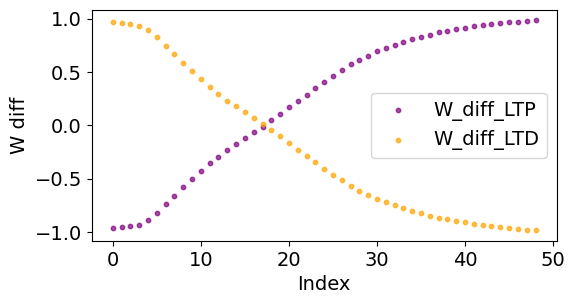

: 

In [ ]:
W_diff_LTP = W_LTP_padded - W_LTD_padded
plt.figure(figsize=(6,3))
plt.scatter(np.arange(len(W_diff_LTP)), W_diff_LTP, c='purple', s=10, label='W_diff_LTP', alpha=0.7)
plt.xlabel('Index')
plt.ylabel('W_diff_LTP')

W_diff_LTD = W_LTD_padded - W_LTP_padded
plt.scatter(np.arange(len(W_diff_LTD)), W_diff_LTD, c='orange', s=10, label='W_diff_LTD', alpha=0.7)
plt.xlabel('Index')
plt.ylabel('W diff')
#Show legend
plt.legend()


#Calculate the dW arrays for the differential arrays
Winit_diff_LTP = W_diff_LTP[:-1]         # all except last
Wfinal_diff_LTP = W_diff_LTP[1:]         # all except first
dW_diff_LTP = Wfinal_diff_LTP - Winit_diff_LTP
W_diff_LTP = Winit_diff_LTP  # update W_diff_LTP to match dW_diff_LTP length
W_diff_LTD = W_LTD_padded - W_LTP_padded
Winit_diff_LTD = W_diff_LTD[:-1]         # all except last
Wfinal_diff_LTD = W_diff_LTD[1:]         # all except first
dW_diff_LTD = Wfinal_diff_LTD - Winit_diff_LTD
W_diff_LTD = Winit_diff_LTD  # update W_diff_LTD to match dW_diff_LTD length


#Save LTP and LTD data as csv in a single file as lists
# Save arrays without padding
np.savez_compressed(f'LTP_LTD_data_{file_name}.npz', W_LTP=W_LTP, dW_LTP=dW_LTP, W_LTD=W_LTD, dW_LTD=dW_LTD
                    , W_diff_LTP=W_diff_LTP, dW_diff_LTP=dW_diff_LTP, W_diff_LTD=W_diff_LTD, dW_diff_LTD=dW_diff_LTD
                    
                    )

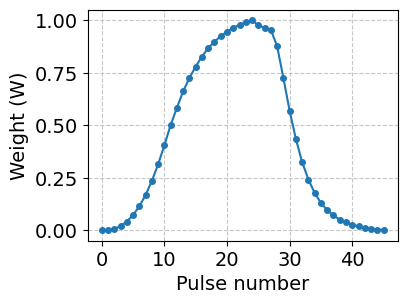

In [8]:
#Plot the W against index for this selected cycle
plt.figure(figsize=(4,3))
plt.plot(np.arange(len(W)), W, marker='o', linestyle='-', markersize=4)
plt.xlabel('Pulse number')
plt.ylabel('Weight (W)')
#Add grids
plt.grid(True, linestyle='--', alpha=0.7)

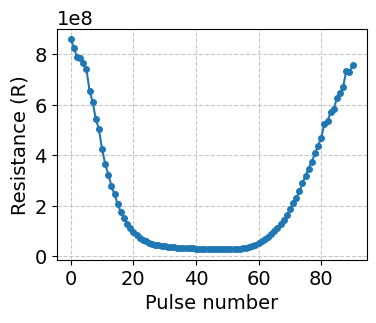

In [74]:
#Plot the R against index for this selected cycle
plt.figure(figsize=(4,3))
plt.plot(np.arange(len(cycle_R)), cycle_R, marker='o', linestyle='-', markersize=4)
plt.xlabel('Pulse number')
plt.ylabel('Resistance (R)')
#Add grids
plt.grid(True, linestyle='--', alpha=0.7)